In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import figure

In [2]:
df = pd.read_csv("../data/main_data.csv")

# Clleaning data & formating it

In [3]:
df.dropna(subset=["CustomerID"], inplace=True)
df.drop(df[(df["Quantity"]<0)].index, inplace=True)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["UnitPrice"] = pd.to_numeric(
    df["UnitPrice"].str.replace(",", ".", regex=False),
    errors="raise"
)
df.info()

/tmp/ipykernel_81995/253841723.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])


<class 'pandas.DataFrame'>
Index: 397924 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397924 non-null  str           
 1   StockCode    397924 non-null  str           
 2   Description  397924 non-null  str           
 3   Quantity     397924 non-null  int64         
 4   InvoiceDate  397924 non-null  datetime64[us]
 5   UnitPrice    397924 non-null  float64       
 6   CustomerID   397924 non-null  float64       
 7   Country      397924 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 27.3 MB


In [4]:
nominal = df[["InvoiceDate", "StockCode", "Description","CustomerID", "Country"]]
ordinal = df[["InvoiceDate"]]
discrete = df[["Quantity"]]
continuous = df[["UnitPrice"]]

# Data visualization

### Customers per country

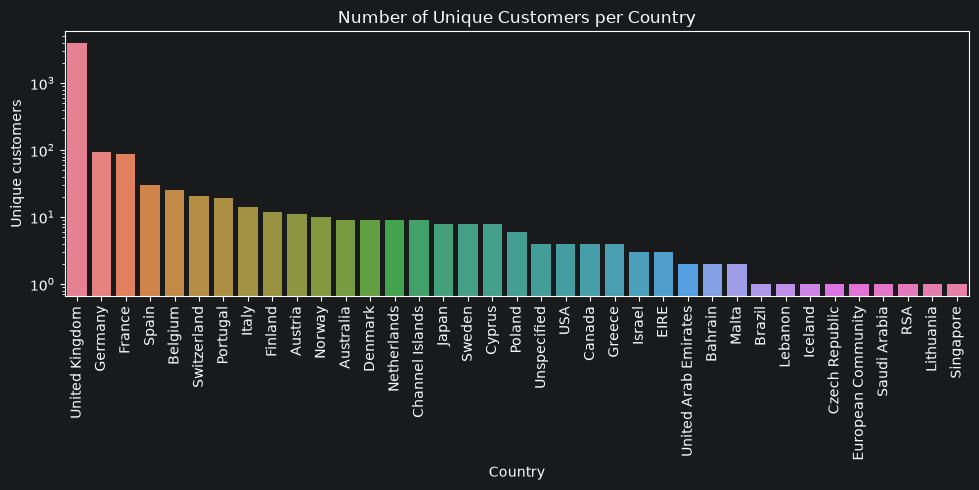

In [5]:
cust_per_country = (
    df.groupby("Country")["CustomerID"]
      .nunique()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=cust_per_country.index, y=cust_per_country.values,
            hue=cust_per_country.index, legend=False)
plt.title("Number of Unique Customers per Country")
plt.ylabel("Unique customers")
plt.xlabel("Country")
plt.xticks(rotation=90)
plt.tight_layout()
plt.yscale("log")
plt.show()

### Sales per countery

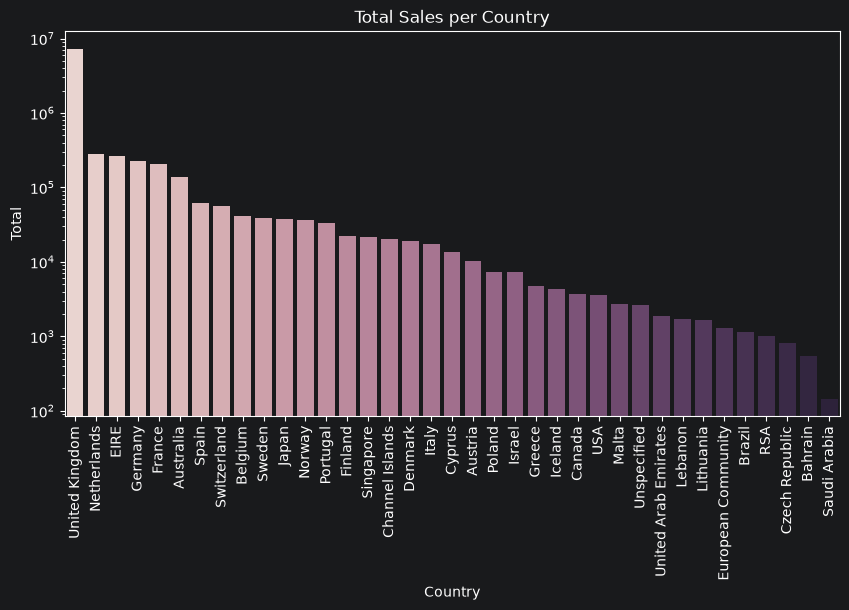

In [16]:
df["Total"] = df["Quantity"] * df["UnitPrice"]

data = (
    df.groupby("Country")["Total"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(data=data, x="Country", y="Total", hue=data.index, legend=False)
plt.xticks(rotation=90)
plt.title("Total Sales per Country")
plt.yscale("log")
plt.show()

# RFM

### Monetary

In [15]:
RFM = pd.DataFrame(df["CustomerID"].unique(), columns=["CustomerID"])
RFM = df.groupby("CustomerID")["Total"].sum().rename("Monetary").reset_index()
RFM

,CustomerID,Monetary
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40
...,...,...
4334,18280.0,180.60
4335,18281.0,80.82
4336,18282.0,178.05
4337,18283.0,2094.88


### Recency